# ToDo

# Подготовка

## Настройка графики

In [1]:
# windows.options(height=5.4, width=7)
oldpar <- par()
par(mar = c(8, 4, 1, 2), "xpd" = FALSE)
options(repr.plot.height = 9, repr.plot.width = 12)
options(warn = -1)

## Библиотеки

In [2]:
options(java.parameters = "-Xmx4096m")

require(readxl, quietly = TRUE, warn.conflicts = FALSE)

require(vcd, quietly = TRUE, warn.conflicts = FALSE)
require(coin, quietly = TRUE, warn.conflicts = FALSE)
# independence_test
require(agricolae, quietly = TRUE, warn.conflicts = FALSE)
# HSD.test
require(pgirmess, quietly = TRUE, warn.conflicts = FALSE)
# kruskalmc
require(nortest, quietly = TRUE, warn.conflicts = FALSE)
# for normality test in case of N>5000. ad.test -- Anderson-Darling normality test
require(RcmdrMisc, quietly = TRUE, warn.conflicts = FALSE)
# numSumm

require(beeswarm, quietly = TRUE, warn.conflicts = FALSE)
require(lattice, quietly = TRUE, warn.conflicts = FALSE)
require(mosaic, quietly = TRUE, warn.conflicts = FALSE)
require(ggplot2, quietly = TRUE, warn.conflicts = FALSE)
require(ggpubr, quietly = TRUE, warn.conflicts = FALSE)
# ggqqplot
# require(ggExtra, quietly = TRUE, warn.conflicts = FALSE);
# require(gridExtra, quietly = TRUE, warn.conflicts = FALSE);
# require(ggfortify, quietly = TRUE, warn.conflicts = FALSE);
require(ggalluvial, quietly = TRUE)
# flow diagramm
require(hrbrthemes, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord
require(GGally, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord
require(viridis, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord


require(rstatix, quietly = TRUE)
# identify_outliers
require(dplyr, quietly = TRUE, warn.conflicts = FALSE)
require(tidyr, quietly = TRUE, warn.conflicts = FALSE)
require(tidycmprsk, quietly = TRUE, warn.conflicts = FALSE)
# require(tidyverse, quietly = TRUE, warn.conflicts = FALSE);

require(IRdisplay, quietly = TRUE, warn.conflicts = FALSE)
require(repr, quietly = TRUE, warn.conflicts = FALSE)

require(knitr, quietly = TRUE, warn.conflicts = FALSE)
# Dynamic reports

Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2




The 'mosaic' package masks several functions from core packages in order to add 
additional features.  The original behavior of these functions should not be affected by this.



Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2




Attaching package: 'rstatix'




The following objects are masked from 'package:mosaic':

    cor_test, prop_test, t_test




The following objects are masked from 'package:coin':

    chisq_test, friedman_test, kruskal_test, sign_test, wilcox_test




The following object is masked from 'package:stats':

    filter




## Данные

### Загрузка

In [3]:
# sessionInfo()
# options(encoding = "UTF-8")
lor <- read_excel("C:\\Analysis\\OTOLARING\\Nidelko\\mucous20240825.xlsx", sheet = "данные")
# lor = as.data.frame(lor)

### Преобразование

#### Отбор данных

In [4]:
lor <- lor %>%
  dplyr::select(
    "id", "группа", "локация", "этап", "поле", "круглоклеточная воспалительная инфильтрация",
    "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия",
    "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
  ) %>%
  filter(локация != "полип") %>%
  filter(группа != "ОГ")

# Get data for "КГ1"
og_data <- lor %>%
  filter(группа == "КГ1")

# Create duplicates for other periods
og_t1 <- og_data %>%
  mutate(этап = "6-7 сутки")

og_t2 <- og_data %>%
  mutate(этап = "1-3 мес.")

og_t3 <- og_data %>%
  mutate(этап = "1 год")

# Combine original data with the duplicated data
lor <- lor %>%
  bind_rows(og_t1, og_t2, og_t3)

lor <- as.data.frame(lor)

#### Контрасты

In [5]:
lor$группа <- factor(lor$группа, c("КГ", "КГ1"))
lor$"локация" <- factor(lor$"локация")
lor$"этап" <- factor(lor$"этап", c("день операции", "6-7 сутки", "1-3 мес.", "1 год"))

#### Медианные значения

In [6]:
lor_mean <- lor %>%
  group_by(id, группа, локация, этап) %>%
  summarise(
    across(
      c(
        "круглоклеточная воспалительная инфильтрация",
        "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия",
        "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
      ),
      ~ median(.x, na.rm = TRUE)
    ),
    .groups = "drop"
    # mean_value = mean(measurement_value, na.rm = TRUE),
    # median_value = median(measurement_value, na.rm = TRUE),
    # sd_value = sd(measurement_value, na.rm = TRUE),
    # min_value = min(measurement_value, na.rm = TRUE),
    # max_value = max(measurement_value, na.rm = TRUE)
  ) %>%
  arrange(id)
# %>%
#     kable(digits = 2)
# lor_mean

### Подключение

In [7]:
try(detach(lor), silent = TRUE)
attach(lor)

# Общий анализ

In [8]:
groupping_variable <- "группа"

## круглоклеточная воспалительная инфильтрация

### Общее

In [9]:
parname <- "круглоклеточная воспалительная инфильтрация"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

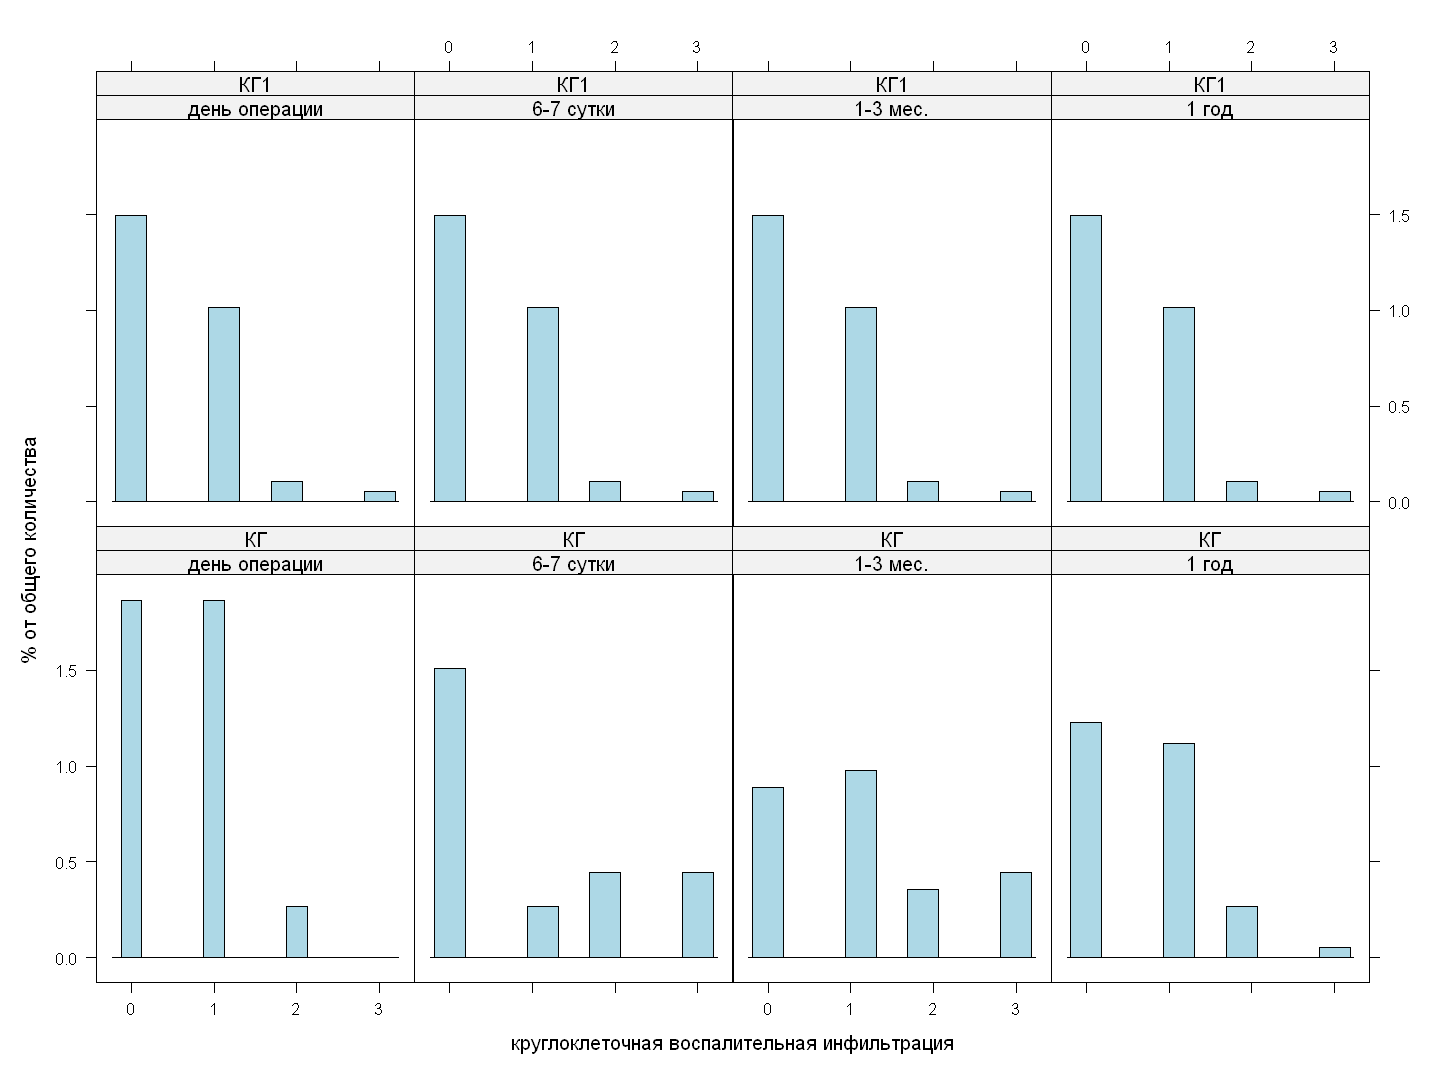

In [10]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [11]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ": ", этап)
)
favstats(values ~ parameter + этап)

                        mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.       1.1333333 1.0742546   2  0   0   1   2    3     30
КГ: 1 год          0.6800000 0.7406561   1  0   0   1   1    3     50
КГ: 6-7 сутки      0.9333333 1.2015316   2  0   0   0   2    3     30
КГ: день операции  0.6000000 0.6324555   1  0   0   1   1    2     15
КГ1: 1-3 мес.      0.5200000 0.6773297   1  0   0   0   1    3     50
КГ1: 1 год         0.5200000 0.6773297   1  0   0   0   1    3     50
КГ1: 6-7 сутки     0.5200000 0.6773297   1  0   0   0   1    3     50
КГ1: день операции 0.5200000 0.6773297   1  0   0   0   1    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
КГ.день операции,0,0,1,1,2,0.6000000,0.6324555,15,0
КГ1.день операции,0,0,0,1,3,0.5200000,0.6773297,50,0
КГ.6-7 сутки,0,0,0,2,3,0.9333333,1.2015316,30,0
КГ1.6-7 сутки,0,0,0,1,3,0.5200000,0.6773297,50,0
КГ.1-3 мес.,0,0,1,2,3,1.1333333,1.0742546,30,0
КГ1.1-3 мес.,0,0,0,1,3,0.5200000,0.6773297,50,0
КГ.1 год,0,0,1,1,3,0.6800000,0.7406561,50,0
КГ1.1 год,0,0,0,1,3,0.5200000,0.6773297,50,0


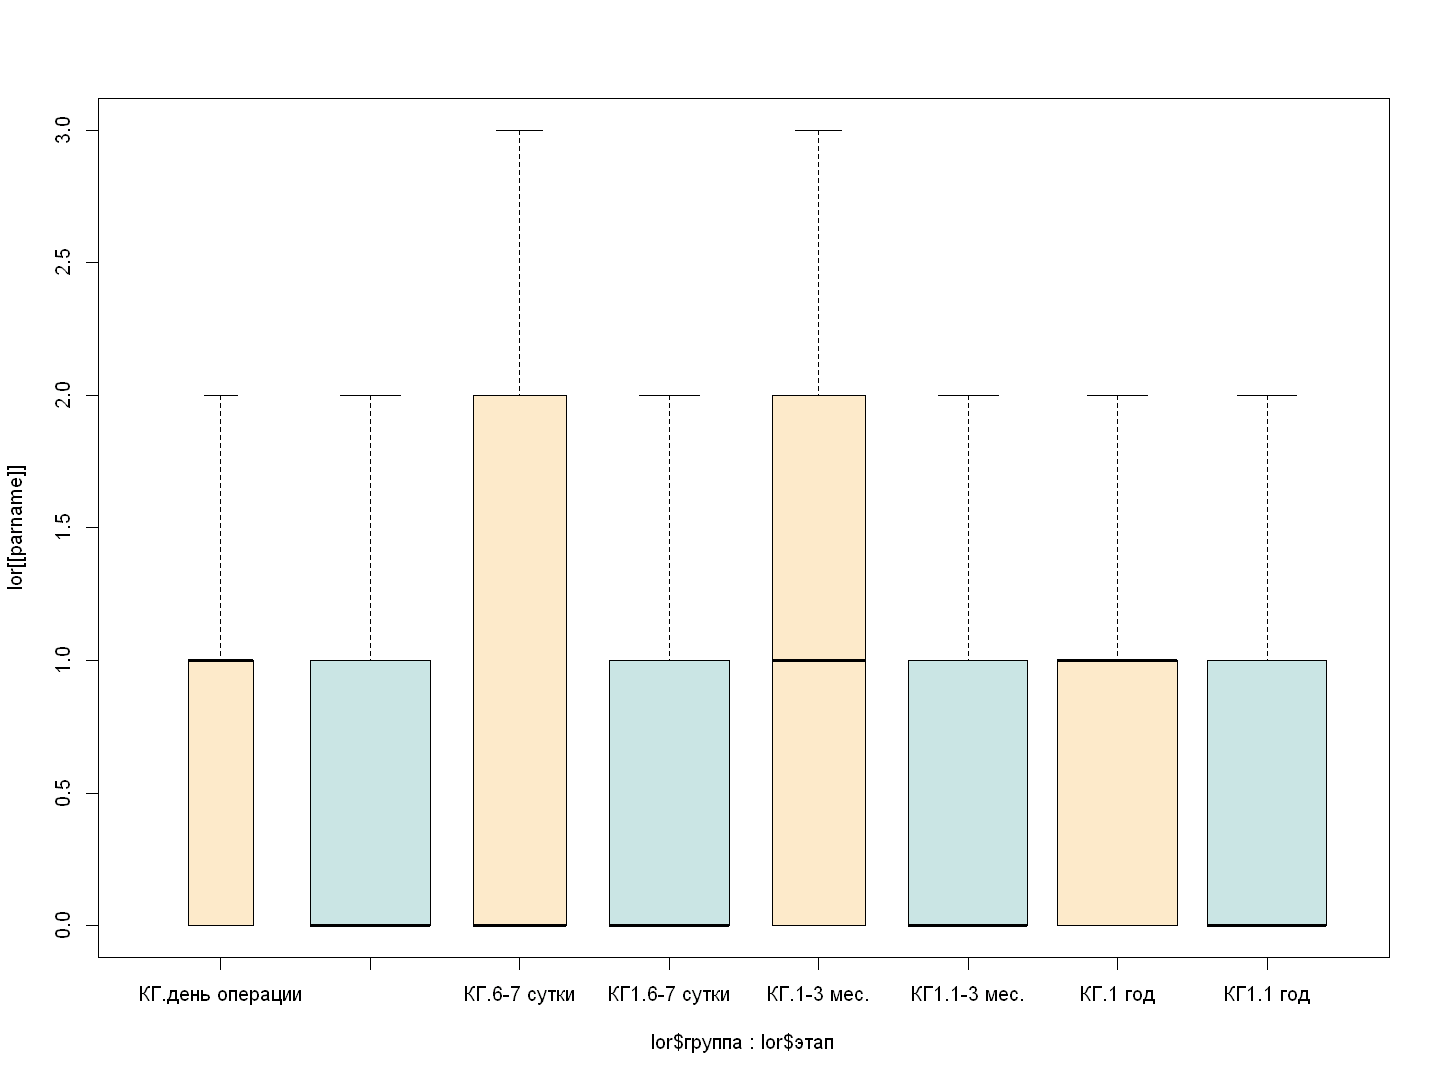

In [12]:
parname <- sub("\\..*", "", parname)
# # beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
# #          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1, 0.6, 0, 0.2), rgb(0, 0.5, 0.5, 0.2)))
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [13]:
for (phase in levels(этап)) {
  tmp <- lor %>%
    filter(этап == phase)
  values <- tmp[[parname]]
  parameter <- tmp[[groupping_variable]]
  cat("================= Этап --", phase)
  if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    print(independence_test(values ~ parameter,
      data = lor,
      alternative = "two.sided",
      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
      xtrafo = function(data) trafo(data, ordered_trafo = ff)
    ))
  } else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
      for (j in (i + 1):nlevels(parameter)) {
        cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
        ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
        try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
        print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
          data = ss,
          alternative = "two.sided",
          distribution = "exact",
          ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
          xtrafo = function(data) trafo(data, ordered_trafo = ff)
        ))
      }
    }
  }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 408.5, p-value = 0.5607
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 0.5906, p-value = 0.5548
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 838, p-value = 0.331
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 0.97762, p-value = 0.3283
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 992, p-value = 0.008803
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 2.6251, p-value = 

## бокаловидные клетки

### Общее

In [14]:
parname <- "бокаловидные клетки"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [15]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [16]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ": ", этап)
)
favstats(values ~ parameter + этап)

                        mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.       0.5666667 0.8172002   1  0   0   0   1    3     30
КГ: 1 год          0.6800000 0.9987748   1  0   0   0   1    3     50
КГ: 6-7 сутки      0.0000000 0.0000000   0  0   0   0   0    0     30
КГ: день операции  0.0000000 0.0000000   0  0   0   0   0    0     15
КГ1: 1-3 мес.      0.3800000 0.6667007   1  0   0   0   1    2     50
КГ1: 1 год         0.3800000 0.6667007   1  0   0   0   1    2     50
КГ1: 6-7 сутки     0.3800000 0.6667007   1  0   0   0   1    2     50
КГ1: день операции 0.3800000 0.6667007   1  0   0   0   1    2     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
КГ.день операции,0,0,0,0,0,0.0000000,0.0000000,15,0
КГ1.день операции,0,0,0,1,2,0.3800000,0.6667007,50,0
КГ.6-7 сутки,0,0,0,0,0,0.0000000,0.0000000,30,0
КГ1.6-7 сутки,0,0,0,1,2,0.3800000,0.6667007,50,0
КГ.1-3 мес.,0,0,0,1,3,0.5666667,0.8172002,30,0
КГ1.1-3 мес.,0,0,0,1,2,0.3800000,0.6667007,50,0
КГ.1 год,0,0,0,1,3,0.6800000,0.9987748,50,0
КГ1.1 год,0,0,0,1,2,0.3800000,0.6667007,50,0


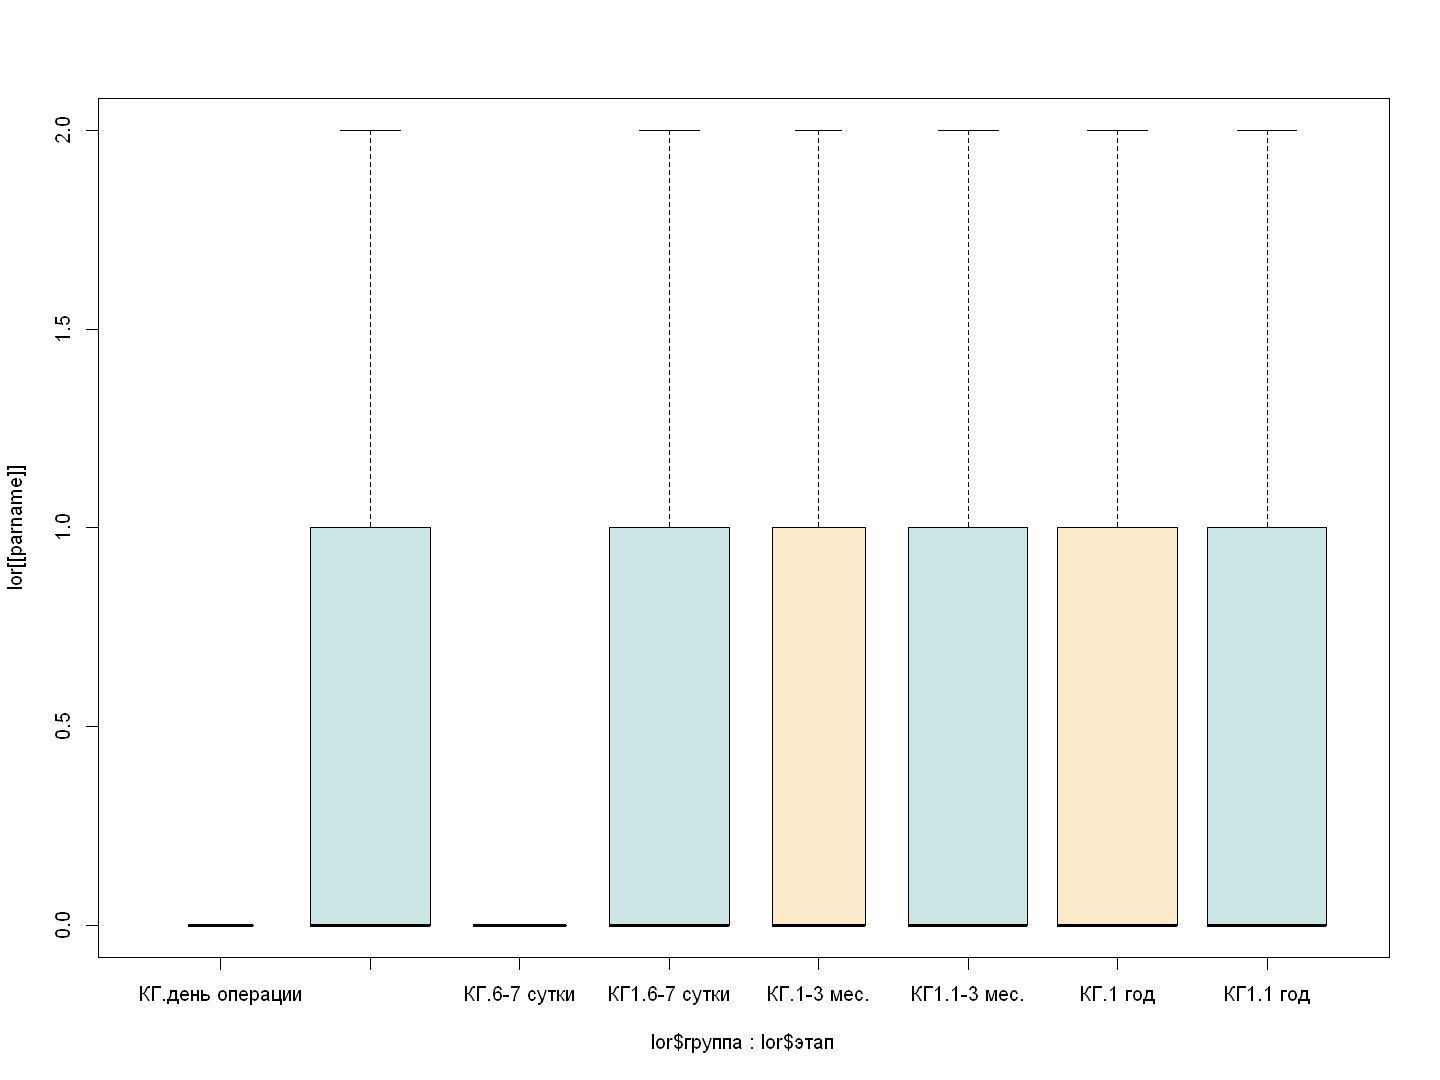

In [17]:
parname <- sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1, 0.6, 0, 0.2), rgb(0, 0.5, 0.5, 0.2)))
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [18]:
for (phase in levels(этап)) {
  tmp <- lor %>%
    filter(этап == phase)
  values <- tmp[[parname]]
  parameter <- tmp[[groupping_variable]]
  cat("================= Этап --", phase)
  if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    print(independence_test(values ~ parameter,
      data = lor,
      alternative = "two.sided",
      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
      xtrafo = function(data) trafo(data, ordered_trafo = ff)
    ))
  } else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
      for (j in (i + 1):nlevels(parameter)) {
        cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
        ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
        try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
        print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
          data = ss,
          alternative = "two.sided",
          distribution = "exact",
          ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
          xtrafo = function(data) trafo(data, ordered_trafo = ff)
        ))
      }
    }
  }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 270, p-value = 0.02324
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = -2.2804, p-value = 0.02259
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 540, p-value = 0.001633
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = -3.1575, p-value = 0.001591
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 840.5, p-value = 0.2788
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 1.0891, p-va

## отек

### Общее

In [19]:
parname <- "отек"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

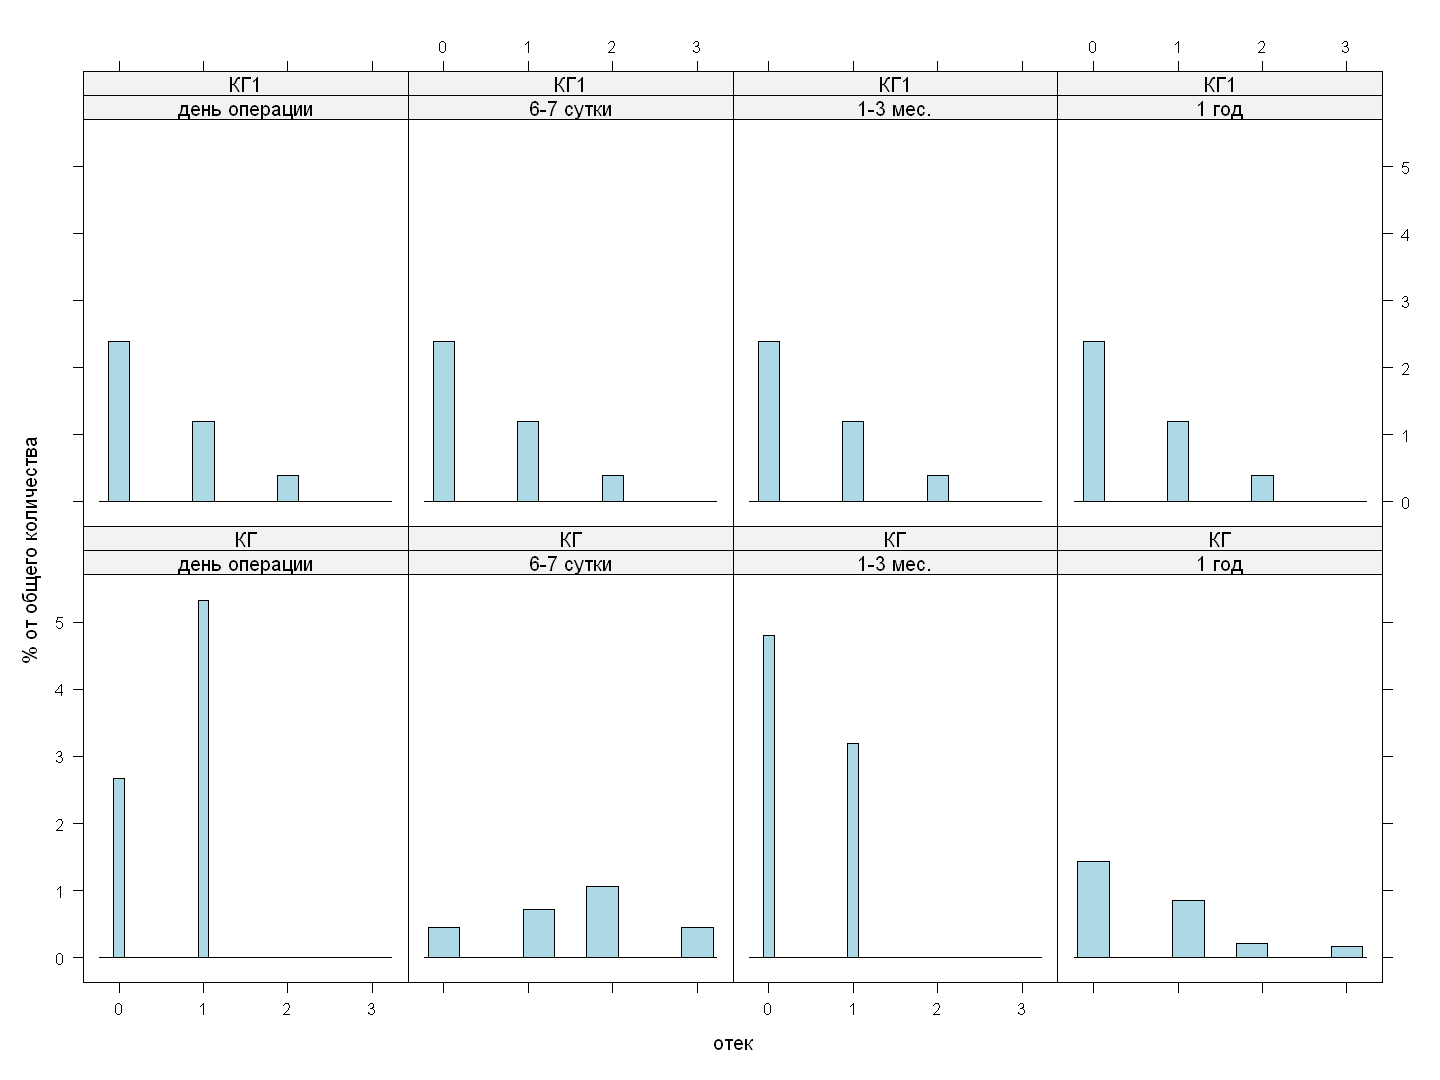

In [20]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [21]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ": ", этап)
)
favstats(values ~ parameter + этап)

                        mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.       0.4000000 0.4982729   1  0   0   0   1    1     30
КГ: 1 год          0.6600000 0.8715457   1  0   0   0   1    3     50
КГ: 6-7 сутки      1.5666667 0.9714310   1  0   1   2   2    3     30
КГ: день операции  0.6666667 0.4879500   1  0   0   1   1    1     15
КГ1: 1-3 мес.      0.5000000 0.6776309   1  0   0   0   1    2     50
КГ1: 1 год         0.5000000 0.6776309   1  0   0   0   1    2     50
КГ1: 6-7 сутки     0.5000000 0.6776309   1  0   0   0   1    2     50
КГ1: день операции 0.5000000 0.6776309   1  0   0   0   1    2     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
КГ.день операции,0,0,1,1,1,0.6666667,0.4879500,15,0
КГ1.день операции,0,0,0,1,2,0.5000000,0.6776309,50,0
КГ.6-7 сутки,0,1,2,2,3,1.5666667,0.9714310,30,0
КГ1.6-7 сутки,0,0,0,1,2,0.5000000,0.6776309,50,0
КГ.1-3 мес.,0,0,0,1,1,0.4000000,0.4982729,30,0
КГ1.1-3 мес.,0,0,0,1,2,0.5000000,0.6776309,50,0
КГ.1 год,0,0,0,1,3,0.6600000,0.8715457,50,0
КГ1.1 год,0,0,0,1,2,0.5000000,0.6776309,50,0


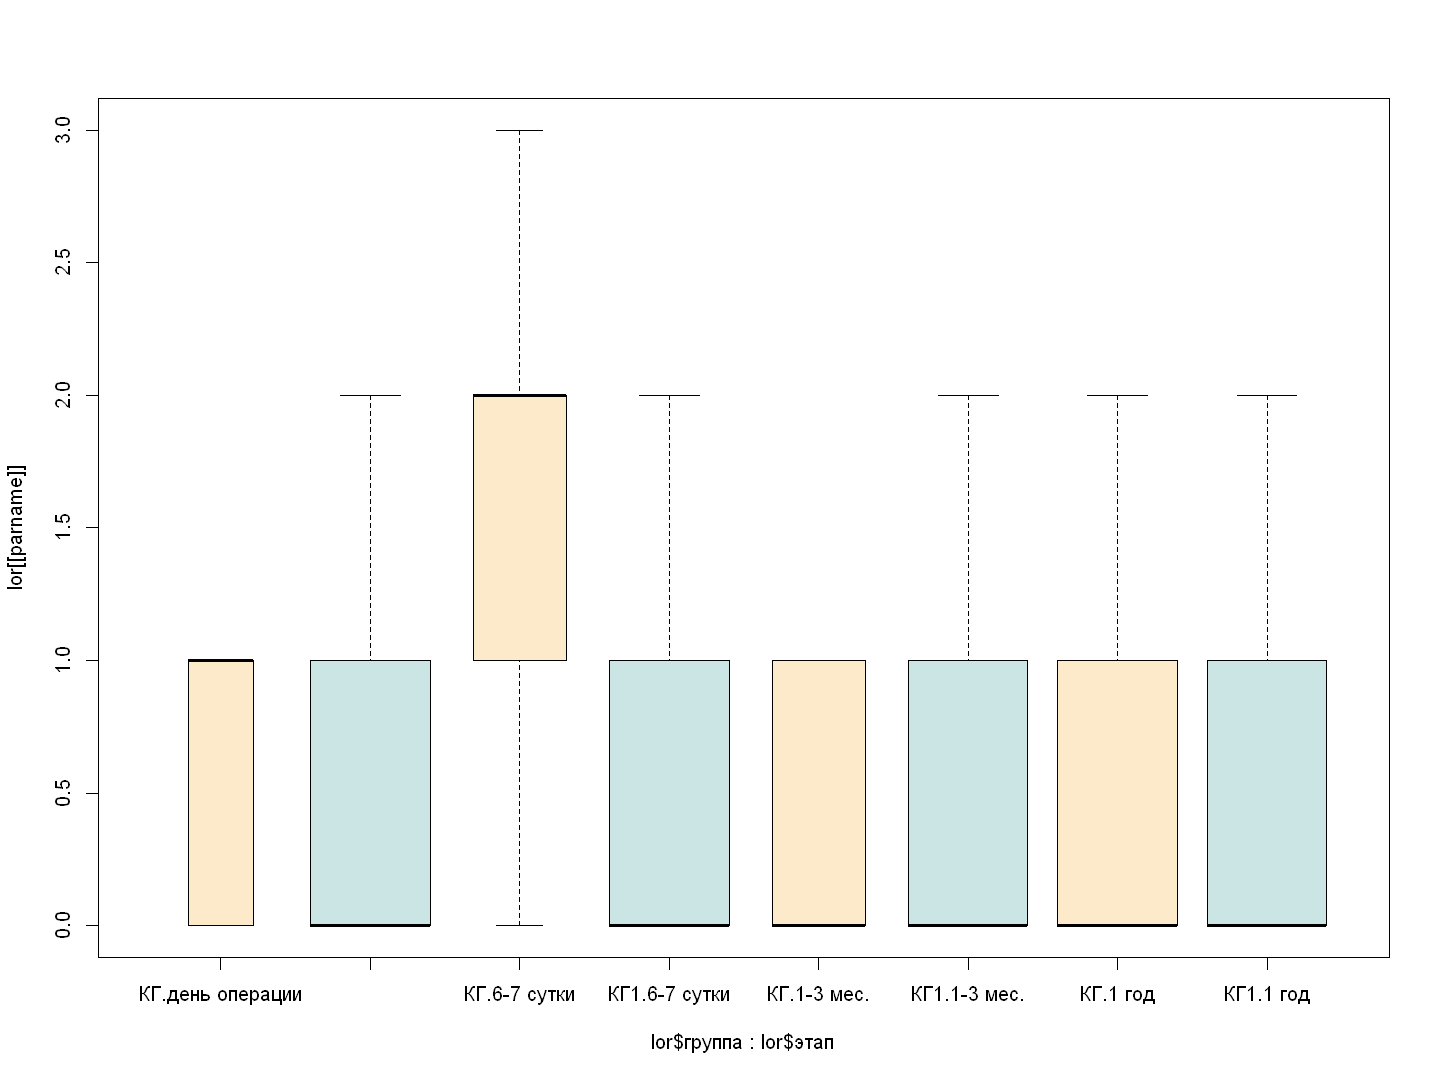

In [22]:
parname <- sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1, 0.6, 0, 0.2), rgb(0, 0.5, 0.5, 0.2)))
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [23]:
for (phase in levels(этап)) {
  tmp <- lor %>%
    filter(этап == phase)
  values <- tmp[[parname]]
  parameter <- tmp[[groupping_variable]]
  cat("================= Этап --", phase)
  if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    print(independence_test(values ~ parameter,
      data = lor,
      alternative = "two.sided",
      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
      xtrafo = function(data) trafo(data, ordered_trafo = ff)
    ))
  } else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
      for (j in (i + 1):nlevels(parameter)) {
        cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
        ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
        try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
        print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
          data = ss,
          alternative = "two.sided",
          distribution = "exact",
          ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
          xtrafo = function(data) trafo(data, ordered_trafo = ff)
        ))
      }
    }
  }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 450, p-value = 0.1909
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 1.3166, p-value = 0.188
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1195, p-value = 2.581e-06
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 4.7069, p-value = 2.515e-06
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 720, p-value = 0.7342
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = -0.34532, p-valu

## реснички эпителия

### Общее

In [24]:
parname <- "реснички эпителия"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

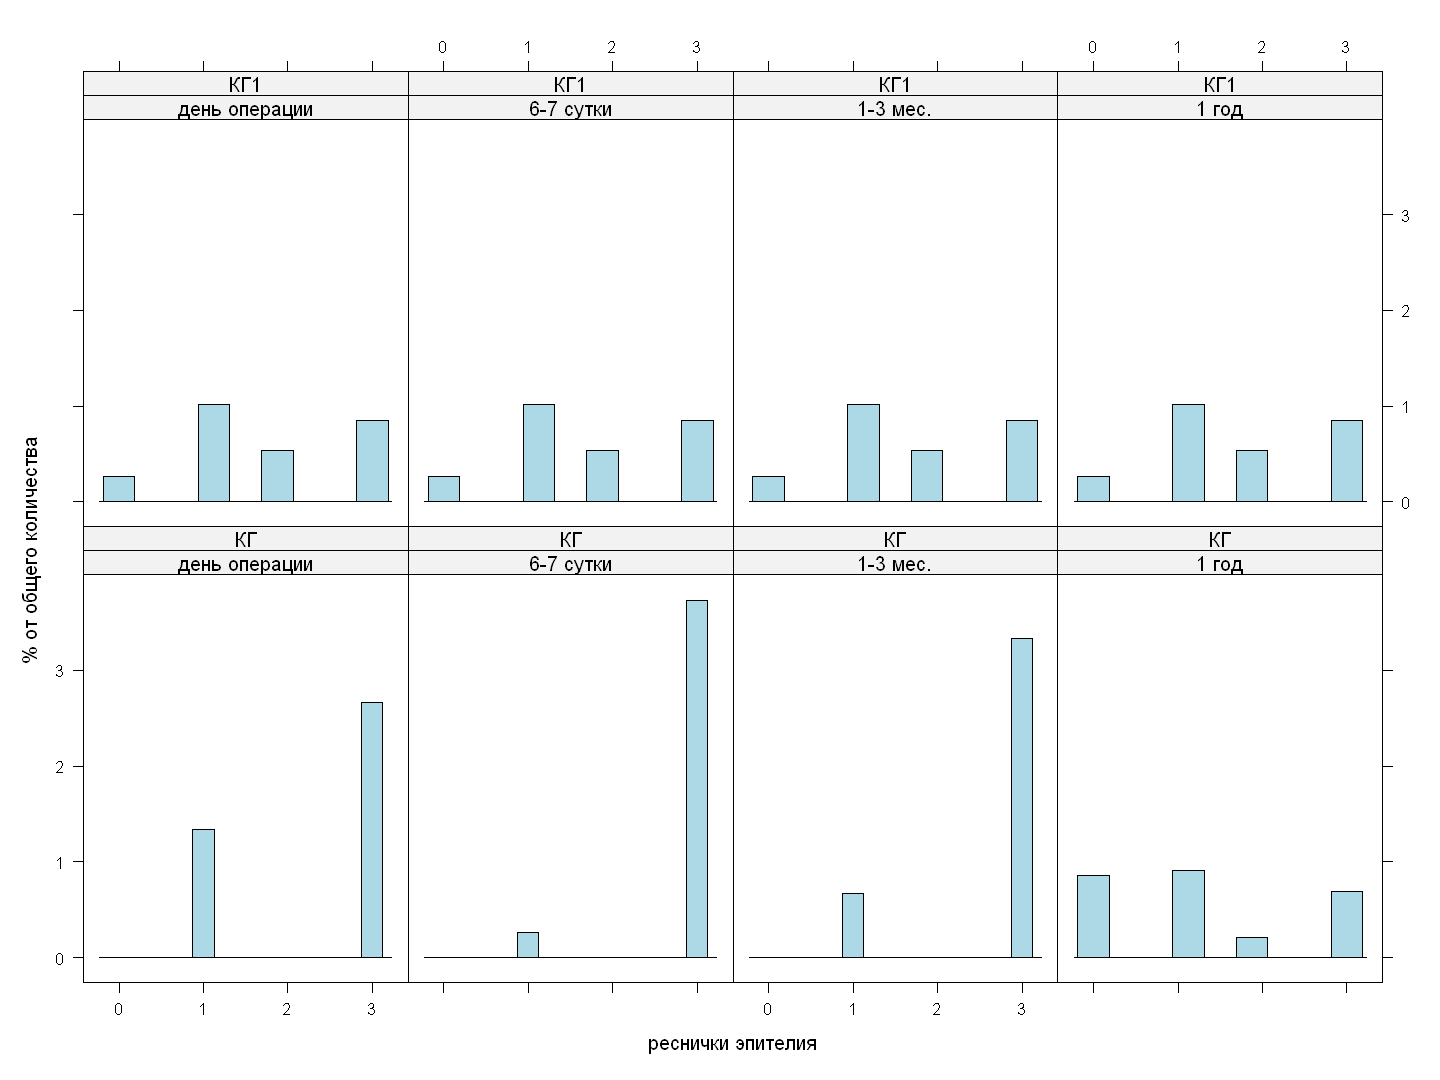

In [25]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [26]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ": ", этап)
)
favstats(values ~ parameter + этап)

                       mean        sd  IQR 0% 25% 50%  75% 100% data:n
КГ: 1-3 мес.       2.666667 0.7580980 0.00  1   3   3 3.00    3     30
КГ: 1 год          1.280000 1.1787229 2.75  0   0   1 2.75    3     50
КГ: 6-7 сутки      2.866667 0.5074163 0.00  1   3   3 3.00    3     30
КГ: день операции  2.333333 0.9759001 2.00  1   1   3 3.00    3     15
КГ1: 1-3 мес.      1.740000 1.0263866 2.00  0   1   2 3.00    3     50
КГ1: 1 год         1.740000 1.0263866 2.00  0   1   2 3.00    3     50
КГ1: 6-7 сутки     1.740000 1.0263866 2.00  0   1   2 3.00    3     50
КГ1: день операции 1.740000 1.0263866 2.00  0   1   2 3.00    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
КГ.день операции,1,1,3,3.00,3,2.333333,0.9759001,15,0
КГ1.день операции,0,1,2,3.00,3,1.740000,1.0263866,50,0
КГ.6-7 сутки,1,3,3,3.00,3,2.866667,0.5074163,30,0
КГ1.6-7 сутки,0,1,2,3.00,3,1.740000,1.0263866,50,0
КГ.1-3 мес.,1,3,3,3.00,3,2.666667,0.7580980,30,0
КГ1.1-3 мес.,0,1,2,3.00,3,1.740000,1.0263866,50,0
КГ.1 год,0,0,1,2.75,3,1.280000,1.1787229,50,0
КГ1.1 год,0,1,2,3.00,3,1.740000,1.0263866,50,0


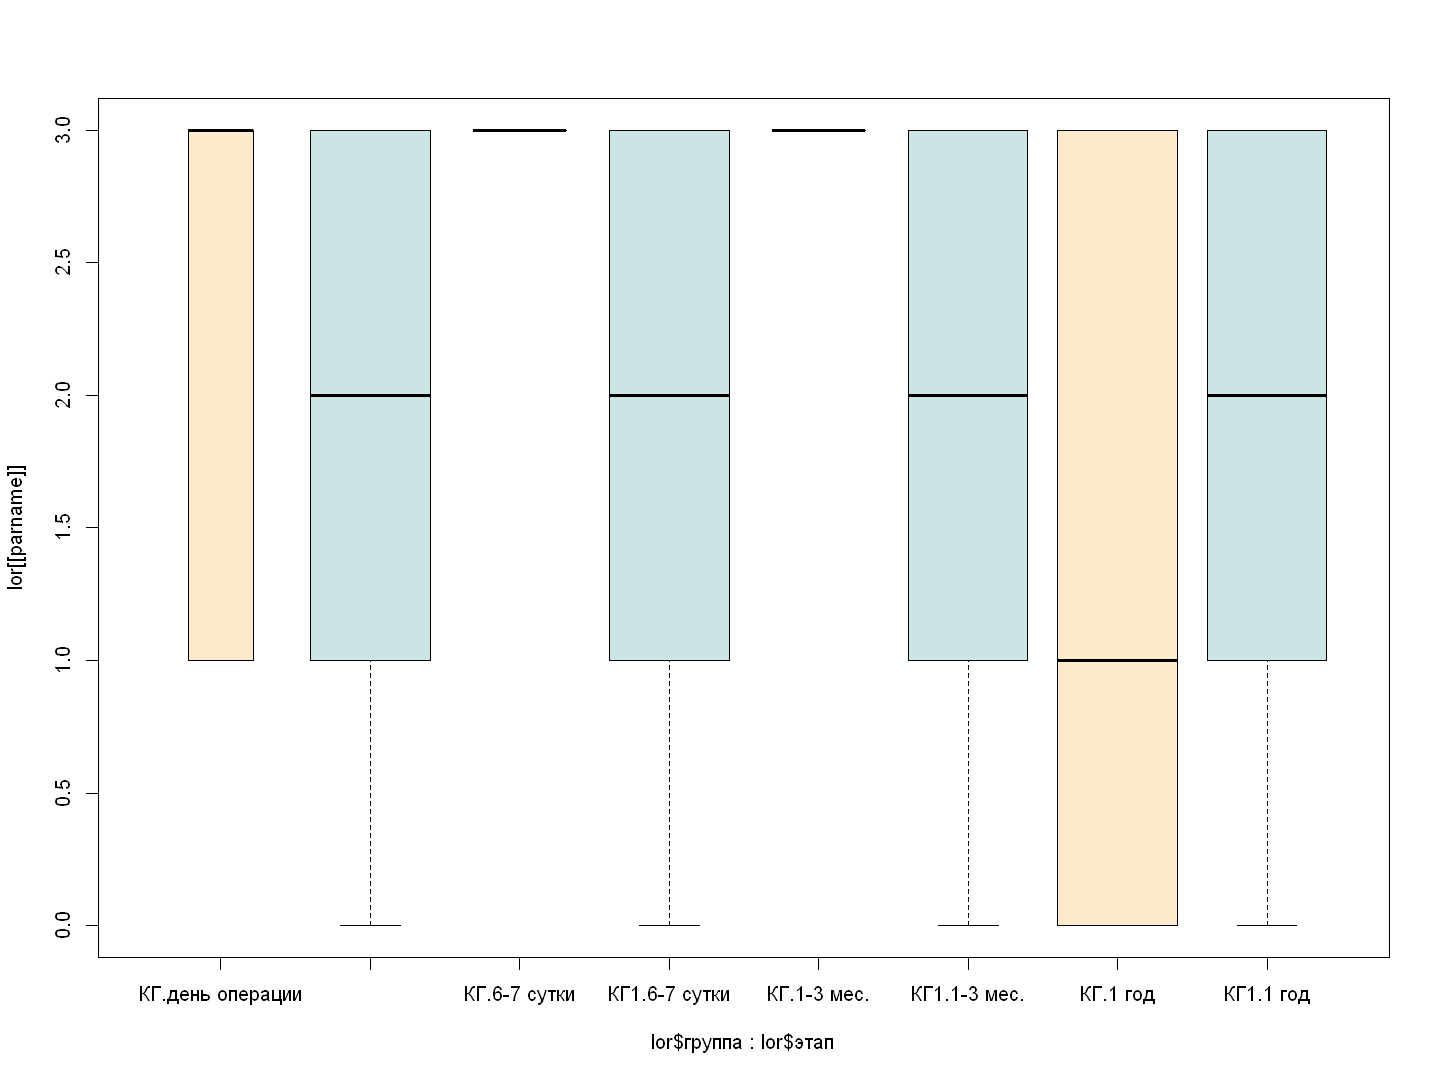

In [27]:
parname <- sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1, 0.6, 0, 0.2), rgb(0, 0.5, 0.5, 0.2)))
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [28]:
for (phase in levels(этап)) {
  tmp <- lor %>%
    filter(этап == phase)
  values <- tmp[[parname]]
  parameter <- tmp[[groupping_variable]]
  cat("================= Этап --", phase)
  if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    print(independence_test(values ~ parameter,
      data = lor,
      alternative = "two.sided",
      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
      xtrafo = function(data) trafo(data, ordered_trafo = ff)
    ))
  } else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
      for (j in (i + 1):nlevels(parameter)) {
        cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
        ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
        try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
        print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
          data = ss,
          alternative = "two.sided",
          distribution = "exact",
          ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
          xtrafo = function(data) trafo(data, ordered_trafo = ff)
        ))
      }
    }
  }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 492.5, p-value = 0.05238
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 1.9483, p-value = 0.05138
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1205, p-value = 5.499e-07
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 5.0135, p-value = 5.344e-07
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1122.5, p-value = 5.287e-05
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 4.048

## фиброз

### Общее

In [29]:
parname <- "фиброз"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

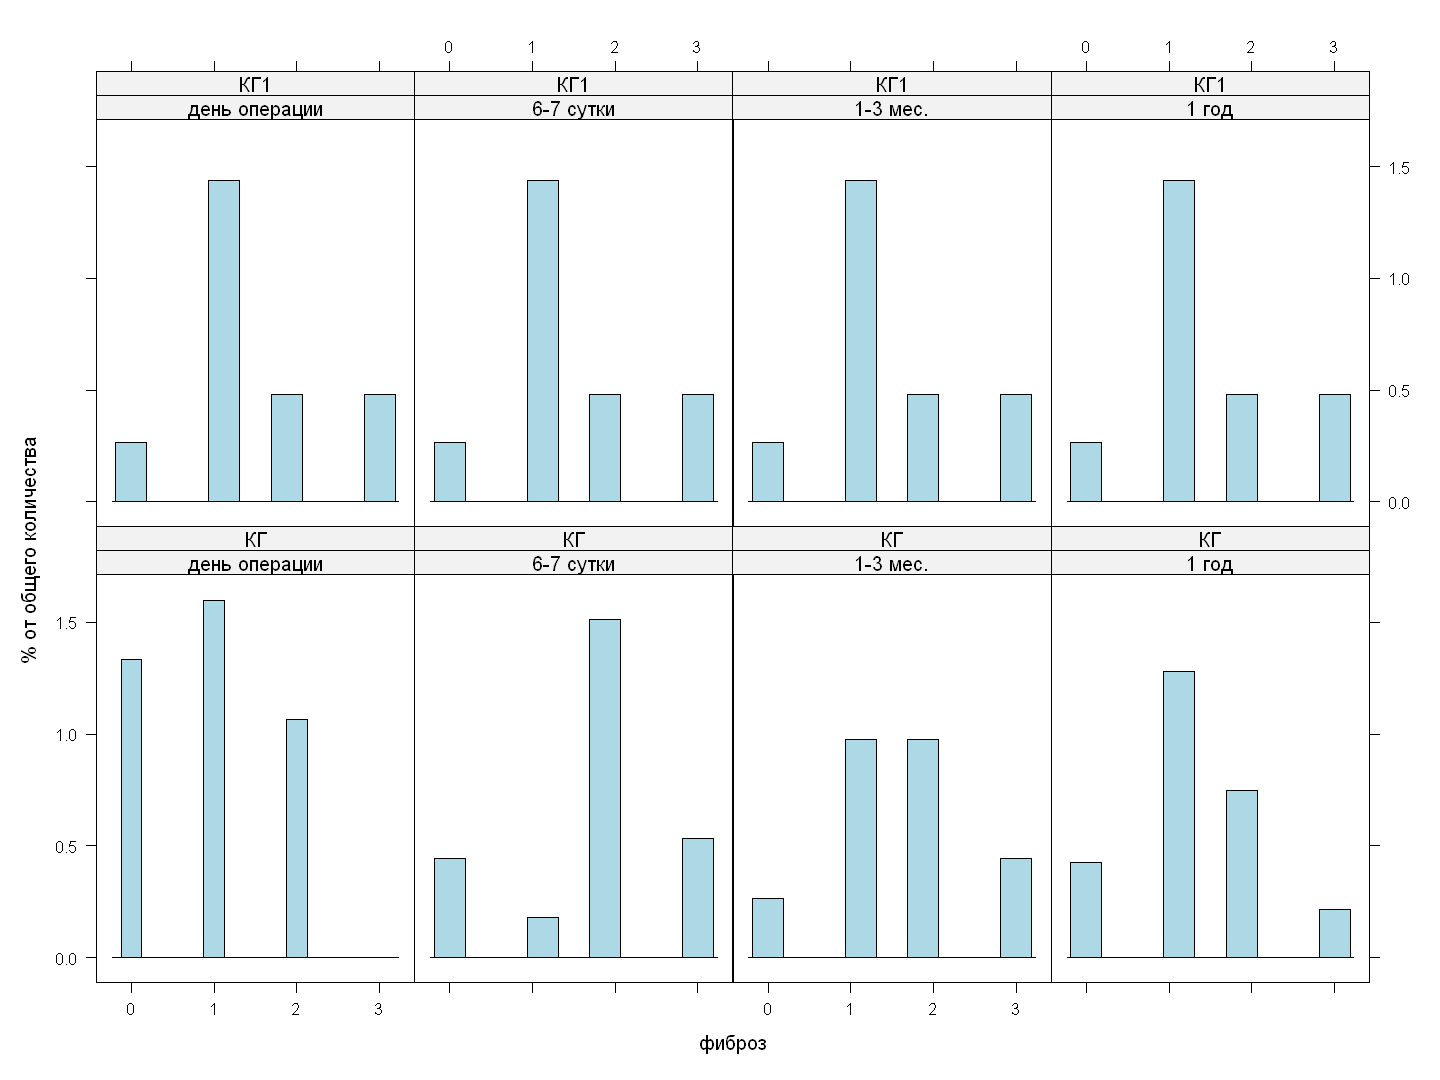

In [30]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [31]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ": ", этап)
)
favstats(values ~ parameter + этап)

                        mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.       1.6000000 0.8944272 1.0  0   1   2 2.0    3     30
КГ: 1 год          1.2800000 0.8339725 1.0  0   1   1 2.0    3     50
КГ: 6-7 сутки      1.8000000 0.9613209 0.0  0   2   2 2.0    3     30
КГ: день операции  0.9333333 0.7988086 1.5  0   0   1 1.5    2     15
КГ1: 1-3 мес.      1.4400000 0.9071147 1.0  0   1   1 2.0    3     50
КГ1: 1 год         1.4400000 0.9071147 1.0  0   1   1 2.0    3     50
КГ1: 6-7 сутки     1.4400000 0.9071147 1.0  0   1   1 2.0    3     50
КГ1: день операции 1.4400000 0.9071147 1.0  0   1   1 2.0    3     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
КГ.день операции,0,0,1,1.5,2,0.9333333,0.7988086,15,0
КГ1.день операции,0,1,1,2.0,3,1.4400000,0.9071147,50,0
КГ.6-7 сутки,0,2,2,2.0,3,1.8000000,0.9613209,30,0
КГ1.6-7 сутки,0,1,1,2.0,3,1.4400000,0.9071147,50,0
КГ.1-3 мес.,0,1,2,2.0,3,1.6000000,0.8944272,30,0
КГ1.1-3 мес.,0,1,1,2.0,3,1.4400000,0.9071147,50,0
КГ.1 год,0,1,1,2.0,3,1.2800000,0.8339725,50,0
КГ1.1 год,0,1,1,2.0,3,1.4400000,0.9071147,50,0


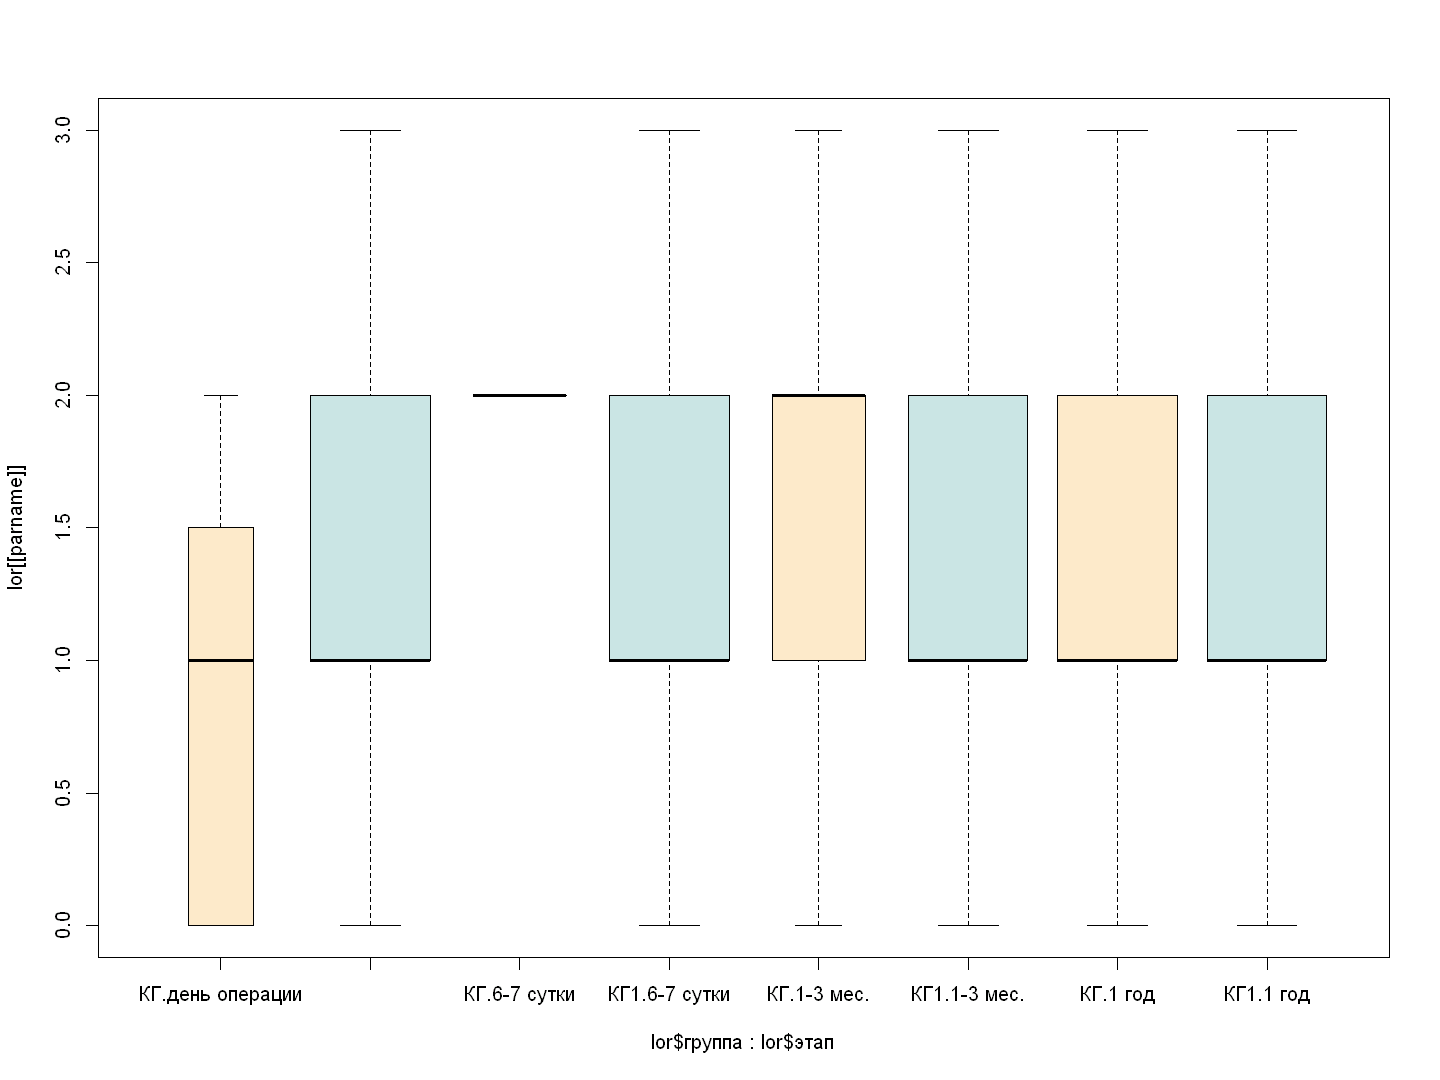

In [32]:
parname <- sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1, 0.6, 0, 0.2), rgb(0, 0.5, 0.5, 0.2)))
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [33]:
for (phase in levels(этап)) {
  tmp <- lor %>%
    filter(этап == phase)
  values <- tmp[[parname]]
  parameter <- tmp[[groupping_variable]]
  cat("================= Этап --", phase)
  if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    print(independence_test(values ~ parameter,
      data = lor,
      alternative = "two.sided",
      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
      xtrafo = function(data) trafo(data, ordered_trafo = ff)
    ))
  } else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
      for (j in (i + 1):nlevels(parameter)) {
        cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
        ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
        try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
        print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
          data = ss,
          alternative = "two.sided",
          distribution = "exact",
          ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
          xtrafo = function(data) trafo(data, ordered_trafo = ff)
        ))
      }
    }
  }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 269.5, p-value = 0.07706
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = -1.7764, p-value = 0.07566
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 943, p-value = 0.04487
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 2.0111, p-value = 0.04432
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 840, p-value = 0.3406
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 0.95839, p-valu

## гиперплазия респираторного эпителия

### Общее

In [34]:
parname <- "гиперплазия респираторного эпителия"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

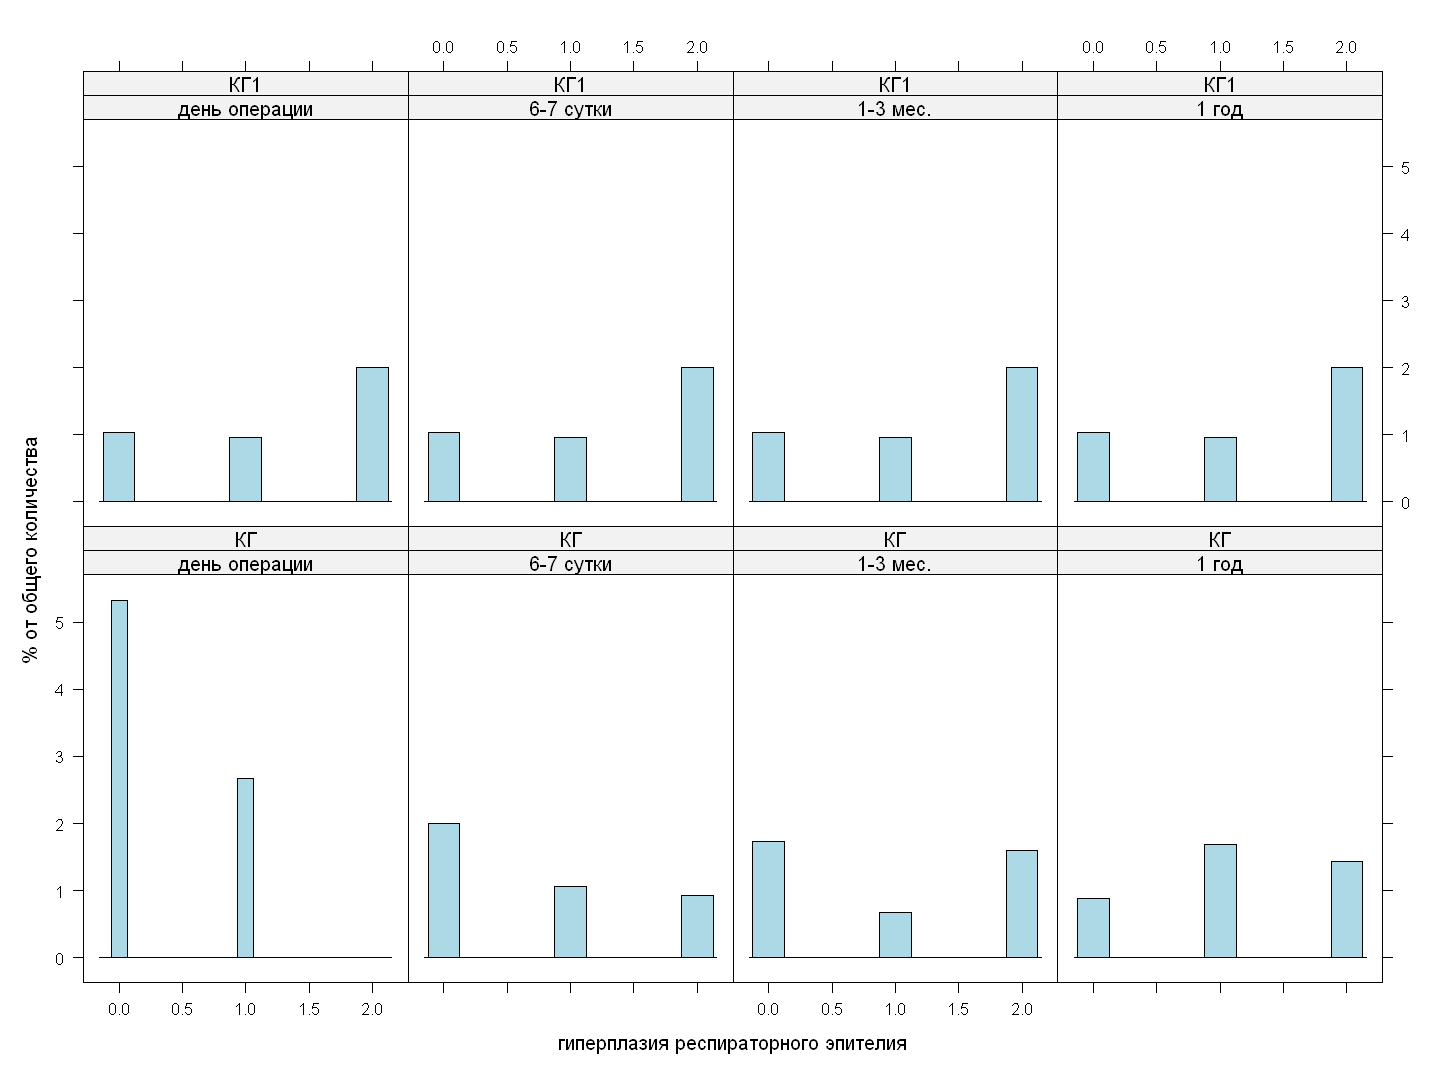

In [35]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [36]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ": ", этап)
)
favstats(values ~ parameter + этап)

                        mean        sd  IQR 0%  25% 50% 75% 100% data:n
КГ: 1-3 мес.       0.9666667 0.9278575 2.00  0 0.00 1.0   2    2     30
КГ: 1 год          1.1400000 0.7561989 1.00  0 1.00 1.0   2    2     50
КГ: 6-7 сутки      0.7333333 0.8276820 1.00  0 0.00 0.5   1    2     30
КГ: день операции  0.3333333 0.4879500 1.00  0 0.00 0.0   1    1     15
КГ1: 1-3 мес.      1.2400000 0.8466019 1.75  0 0.25 1.5   2    2     50
КГ1: 1 год         1.2400000 0.8466019 1.75  0 0.25 1.5   2    2     50
КГ1: 6-7 сутки     1.2400000 0.8466019 1.75  0 0.25 1.5   2    2     50
КГ1: день операции 1.2400000 0.8466019 1.75  0 0.25 1.5   2    2     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
КГ.день операции,0,0.00,0.0,1,1,0.3333333,0.4879500,15,0
КГ1.день операции,0,0.25,1.5,2,2,1.2400000,0.8466019,50,0
КГ.6-7 сутки,0,0.00,0.5,1,2,0.7333333,0.8276820,30,0
КГ1.6-7 сутки,0,0.25,1.5,2,2,1.2400000,0.8466019,50,0
КГ.1-3 мес.,0,0.00,1.0,2,2,0.9666667,0.9278575,30,0
КГ1.1-3 мес.,0,0.25,1.5,2,2,1.2400000,0.8466019,50,0
КГ.1 год,0,1.00,1.0,2,2,1.1400000,0.7561989,50,0
КГ1.1 год,0,0.25,1.5,2,2,1.2400000,0.8466019,50,0


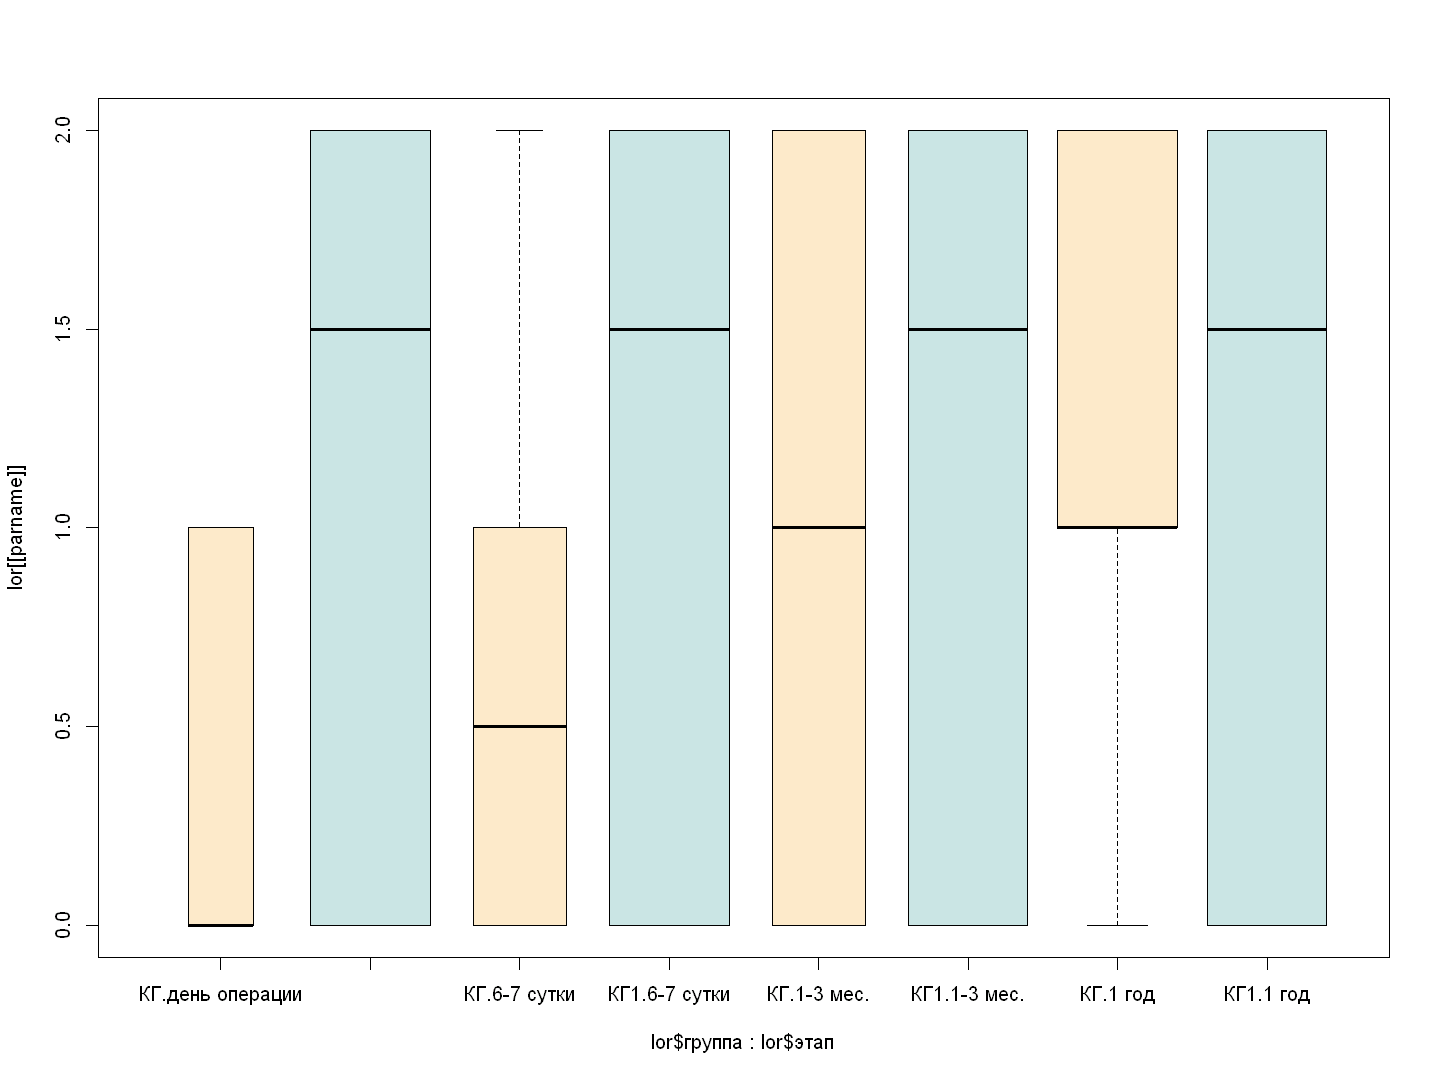

In [37]:
parname <- sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1, 0.6, 0, 0.2), rgb(0, 0.5, 0.5, 0.2)))
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [38]:
for (phase in levels(этап)) {
  tmp <- lor %>%
    filter(этап == phase)
  values <- tmp[[parname]]
  parameter <- tmp[[groupping_variable]]
  cat("================= Этап --", phase)
  if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    print(independence_test(values ~ parameter,
      data = lor,
      alternative = "two.sided",
      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
      xtrafo = function(data) trafo(data, ordered_trafo = ff)
    ))
  } else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
      for (j in (i + 1):nlevels(parameter)) {
        cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
        ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
        try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
        print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
          data = ss,
          alternative = "two.sided",
          distribution = "exact",
          ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
          xtrafo = function(data) trafo(data, ordered_trafo = ff)
        ))
      }
    }
  }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 160, p-value = 0.0003738
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = -3.5662, p-value = 0.0003622
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 512, p-value = 0.01175
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = -2.5248, p-value = 0.01158
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 629.5, p-value = 0.1977
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = -1.2934, p

## плоскоклеточная метаплазия

### Общее

In [39]:
parname <- "плоскоклеточная метаплазия"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

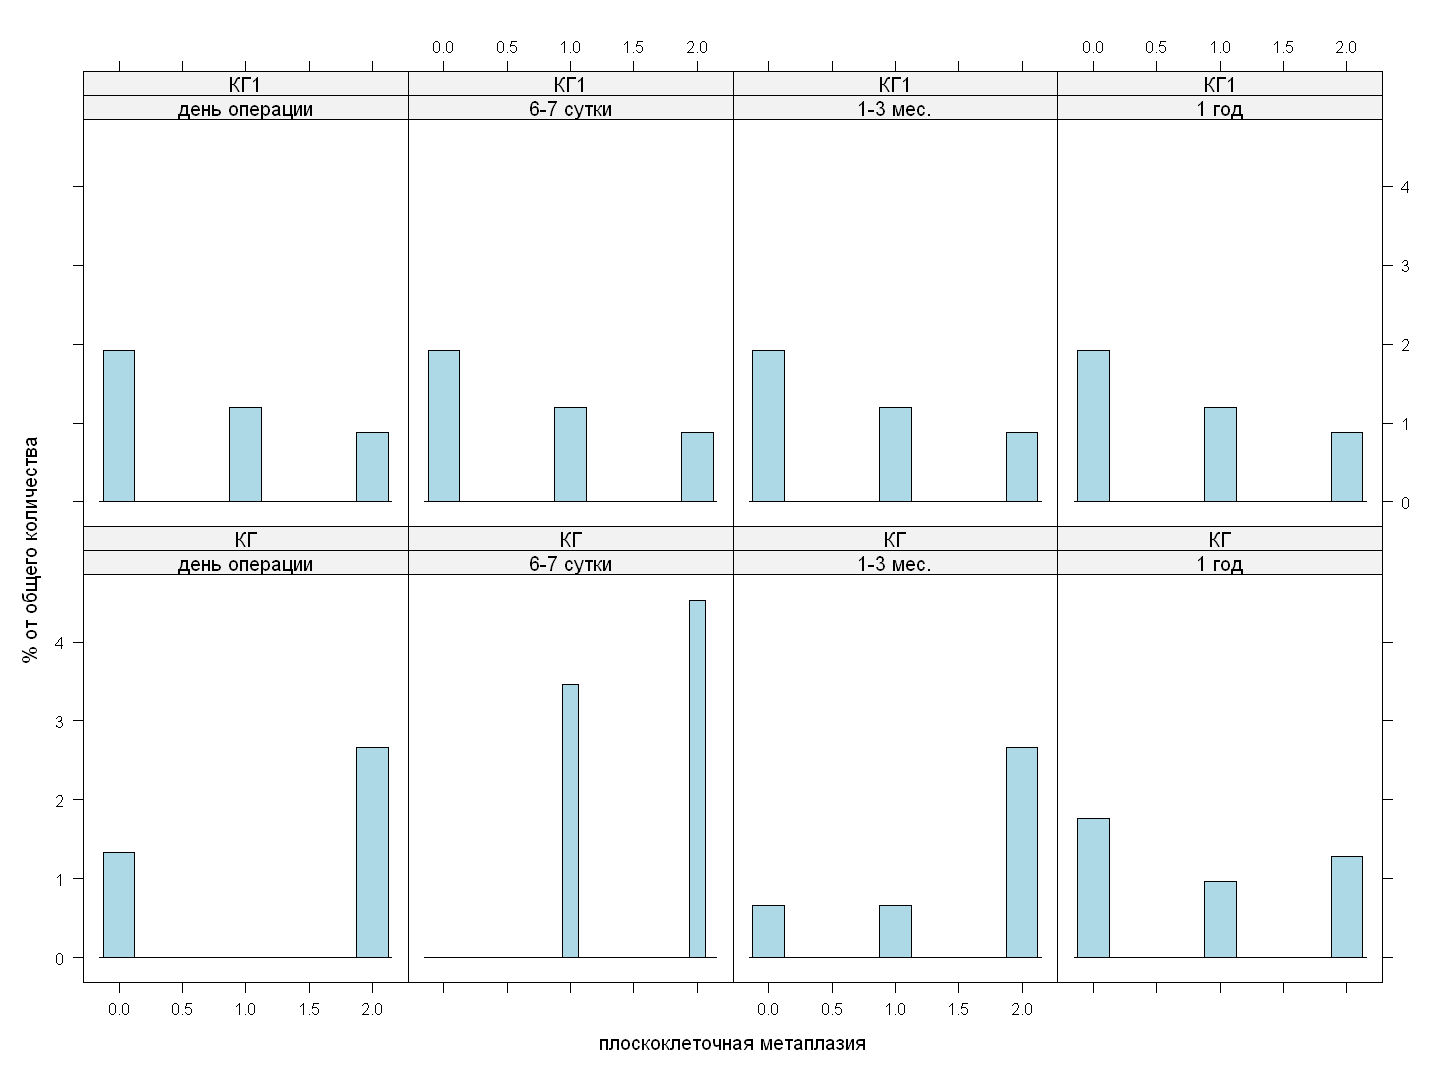

In [40]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [41]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ": ", этап)
)
favstats(values ~ parameter + этап)

                       mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.       1.500000 0.7768193   1  0   1   2   2    2     30
КГ: 1 год          0.880000 0.8722479   2  0   0   1   2    2     50
КГ: 6-7 сутки      1.566667 0.5040069   1  1   1   2   2    2     30
КГ: день операции  1.333333 0.9759001   2  0   0   2   2    2     15
КГ1: 1-3 мес.      0.740000 0.8033095   1  0   0   1   1    2     50
КГ1: 1 год         0.740000 0.8033095   1  0   0   1   1    2     50
КГ1: 6-7 сутки     0.740000 0.8033095   1  0   0   1   1    2     50
КГ1: день операции 0.740000 0.8033095   1  0   0   1   1    2     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
КГ.день операции,0,0,2,2,2,1.333333,0.9759001,15,0
КГ1.день операции,0,0,1,1,2,0.740000,0.8033095,50,0
КГ.6-7 сутки,1,1,2,2,2,1.566667,0.5040069,30,0
КГ1.6-7 сутки,0,0,1,1,2,0.740000,0.8033095,50,0
КГ.1-3 мес.,0,1,2,2,2,1.500000,0.7768193,30,0
КГ1.1-3 мес.,0,0,1,1,2,0.740000,0.8033095,50,0
КГ.1 год,0,0,1,2,2,0.880000,0.8722479,50,0
КГ1.1 год,0,0,1,1,2,0.740000,0.8033095,50,0


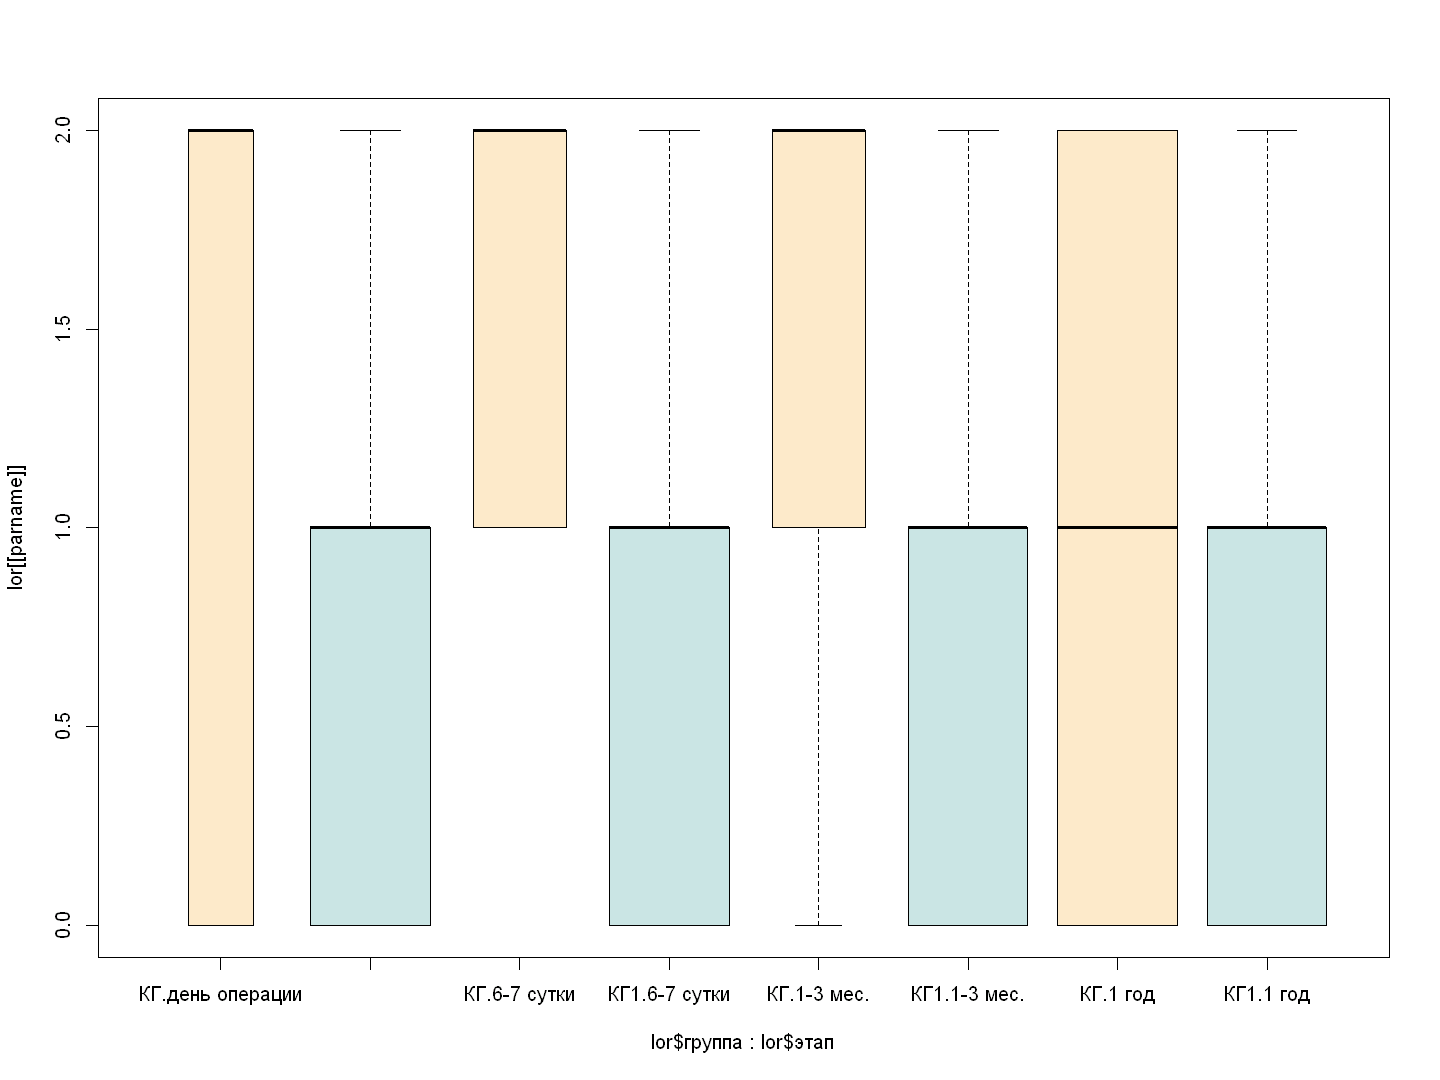

In [42]:
parname <- sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1, 0.6, 0, 0.2), rgb(0, 0.5, 0.5, 0.2)))
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [43]:
for (phase in levels(этап)) {
  tmp <- lor %>%
    filter(этап == phase)
  values <- tmp[[parname]]
  parameter <- tmp[[groupping_variable]]
  cat("================= Этап --", phase)
  if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    print(independence_test(values ~ parameter,
      data = lor,
      alternative = "two.sided",
      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
      xtrafo = function(data) trafo(data, ordered_trafo = ff)
    ))
  } else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
      for (j in (i + 1):nlevels(parameter)) {
        cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
        ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
        try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
        print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
          data = ss,
          alternative = "two.sided",
          distribution = "exact",
          ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
          xtrafo = function(data) trafo(data, ordered_trafo = ff)
        ))
      }
    }
  }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 505, p-value = 0.0302
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 2.1758, p-value = 0.02957
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1166, p-value = 1.168e-05
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 4.3887, p-value = 1.14e-05
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1107.5, p-value = 0.0001538
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 3.7902, p

## эозинофилы

### Общее

In [44]:
parname <- "эозинофилы"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [45]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [46]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ": ", этап)
)
favstats(values ~ parameter + этап)

                        mean        sd IQR 0% 25% 50% 75% 100% data:n
КГ: 1-3 мес.       0.3333333 0.6608946   0  0   0   0   0    2     30
КГ: 1 год          0.7800000 1.2170557   1  0   0   0   1    3     50
КГ: 6-7 сутки      0.0000000 0.0000000   0  0   0   0   0    0     30
КГ: день операции  0.2000000 0.4140393   0  0   0   0   0    1     15
КГ1: 1-3 мес.      0.0000000 0.0000000   0  0   0   0   0    0     50
КГ1: 1 год         0.0000000 0.0000000   0  0   0   0   0    0     50
КГ1: 6-7 сутки     0.0000000 0.0000000   0  0   0   0   0    0     50
КГ1: день операции 0.0000000 0.0000000   0  0   0   0   0    0     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
КГ.день операции,0,0,0,0,1,0.2000000,0.4140393,15,0
КГ1.день операции,0,0,0,0,0,0.0000000,0.0000000,50,0
КГ.6-7 сутки,0,0,0,0,0,0.0000000,0.0000000,30,0
КГ1.6-7 сутки,0,0,0,0,0,0.0000000,0.0000000,50,0
КГ.1-3 мес.,0,0,0,0,2,0.3333333,0.6608946,30,0
КГ1.1-3 мес.,0,0,0,0,0,0.0000000,0.0000000,50,0
КГ.1 год,0,0,0,1,3,0.7800000,1.2170557,50,0
КГ1.1 год,0,0,0,0,0,0.0000000,0.0000000,50,0


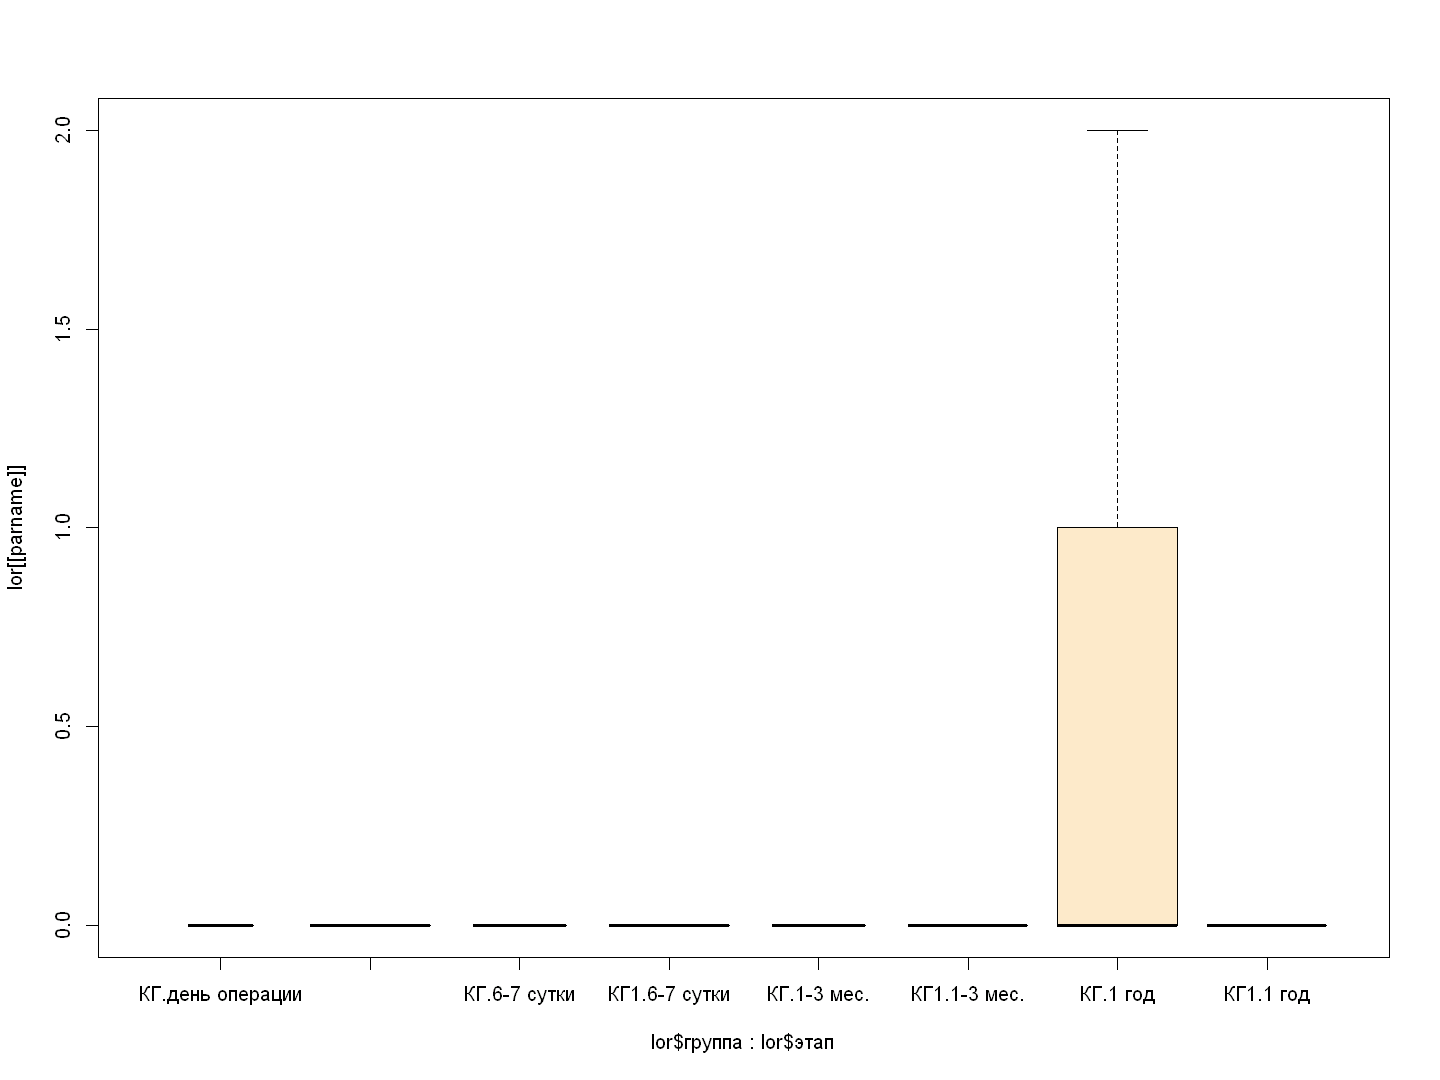

In [47]:
parname <- sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1, 0.6, 0, 0.2), rgb(0, 0.5, 0.5, 0.2)))
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [48]:
for (phase in levels(этап)) {
  tmp <- lor %>%
    filter(этап == phase)
  values <- tmp[[parname]]
  parameter <- tmp[[groupping_variable]]
  cat("================= Этап --", phase)
  if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    print(independence_test(values ~ parameter,
      data = lor,
      alternative = "two.sided",
      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
      xtrafo = function(data) trafo(data, ordered_trafo = ff)
    ))
  } else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
      for (j in (i + 1):nlevels(parameter)) {
        cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
        ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
        try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
        print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
          data = ss,
          alternative = "two.sided",
          distribution = "exact",
          ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
          xtrafo = function(data) trafo(data, ordered_trafo = ff)
        ))
      }
    }
  }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 450, p-value = 0.001416
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 3.2129, p-value = 0.001314
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 750, p-value = NA
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = NaN, p-value = NA
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 925, p-value = 0.0004009
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 3.5496, p-value = 0.000385

## нейтрофилы

### Общее

In [49]:
parname <- "нейтрофилы"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [50]:
try(histogram(~ values | `этап` + parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [51]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = paste0(parameter, ": ", этап)
)
favstats(values ~ parameter + этап)

                        mean        sd  IQR 0% 25% 50%  75% 100% data:n
КГ: 1-3 мес.       0.9666667 1.4015591 3.00  0   0   0 3.00    3     30
КГ: 1 год          0.1200000 0.3282607 0.00  0   0   0 0.00    1     50
КГ: 6-7 сутки      1.5000000 1.1371471 1.75  0   1   1 2.75    3     30
КГ: день операции  0.0000000 0.0000000 0.00  0   0   0 0.00    0     15
КГ1: 1-3 мес.      0.0000000 0.0000000 0.00  0   0   0 0.00    0     50
КГ1: 1 год         0.0000000 0.0000000 0.00  0   0   0 0.00    0     50
КГ1: 6-7 сутки     0.0000000 0.0000000 0.00  0   0   0 0.00    0     50
КГ1: день операции 0.0000000 0.0000000 0.00  0   0   0 0.00    0     50

parameter.этап,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
КГ.день операции,0,0,0,0.00,0,0.0000000,0.0000000,15,0
КГ1.день операции,0,0,0,0.00,0,0.0000000,0.0000000,50,0
КГ.6-7 сутки,0,1,1,2.75,3,1.5000000,1.1371471,30,0
КГ1.6-7 сутки,0,0,0,0.00,0,0.0000000,0.0000000,50,0
КГ.1-3 мес.,0,0,0,3.00,3,0.9666667,1.4015591,30,0
КГ1.1-3 мес.,0,0,0,0.00,0,0.0000000,0.0000000,50,0
КГ.1 год,0,0,0,0.00,1,0.1200000,0.3282607,50,0
КГ1.1 год,0,0,0,0.00,0,0.0000000,0.0000000,50,0


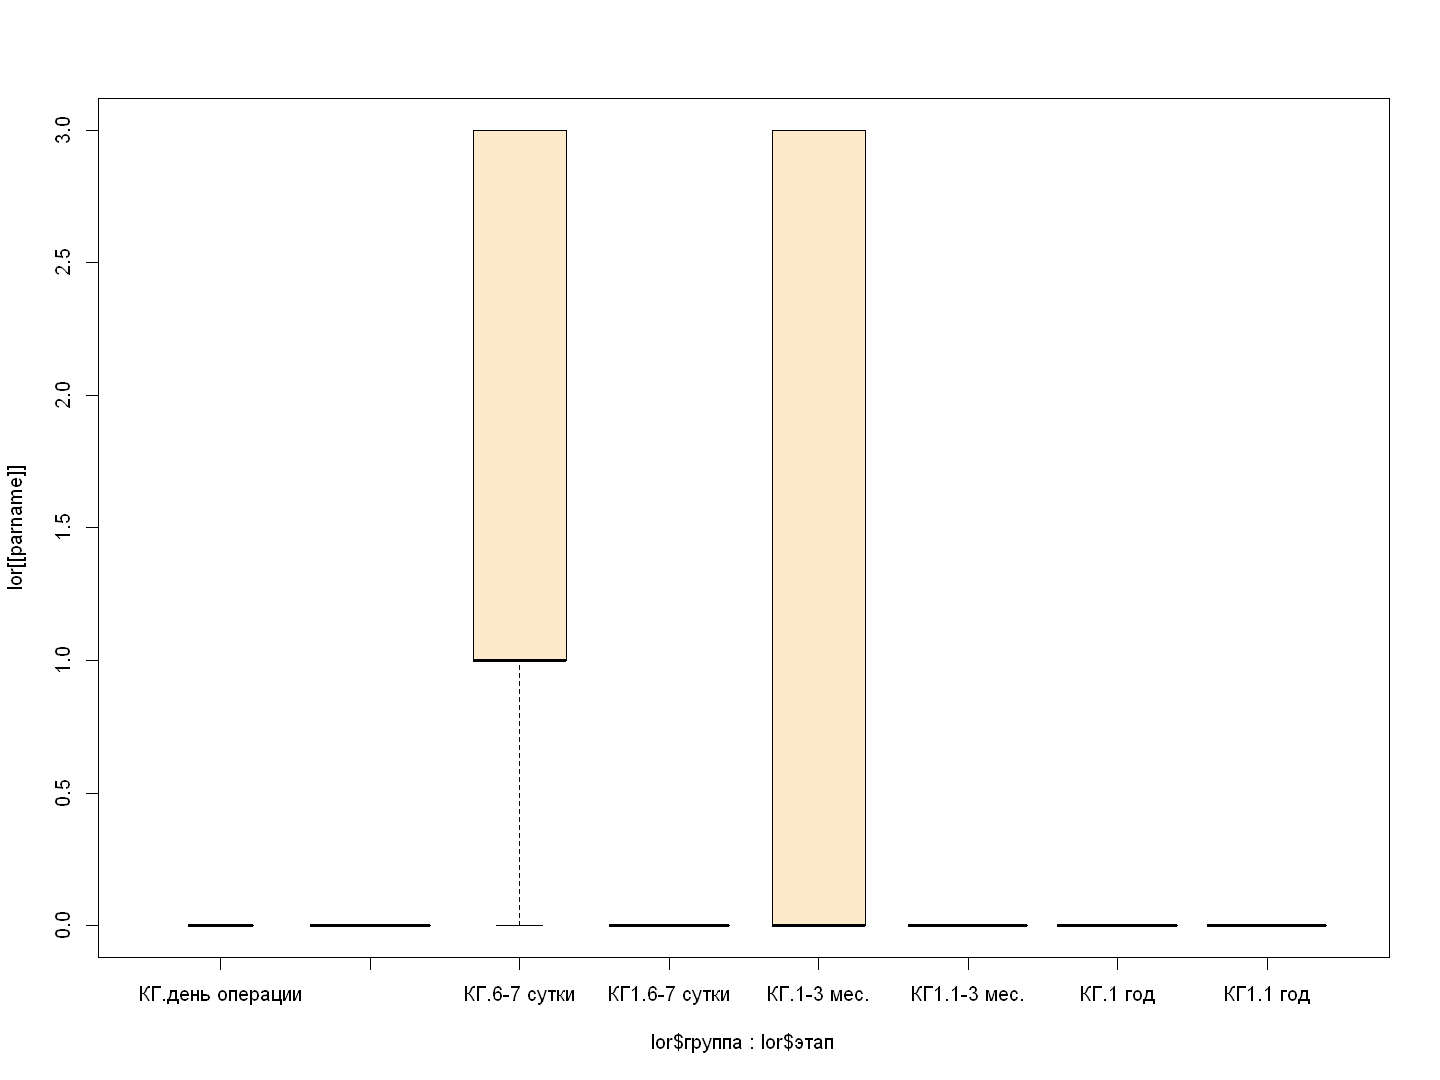

In [52]:
parname <- sub("\\..*", "", parname)
# beeswarm(lor[[parname]] ~ lor$группа + lor$"этап", method = "swarm", pch = 16
#          , xlab = parname, ylab = 'количество', cex=1.2)
boxplot(lor[[parname]] ~ lor$группа + lor$"этап", varwidth = TRUE, outline = FALSE, col = c(rgb(1, 0.6, 0, 0.2), rgb(0, 0.5, 0.5, 0.2)))
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [53]:
for (phase in levels(этап)) {
  tmp <- lor %>%
    filter(этап == phase)
  values <- tmp[[parname]]
  parameter <- tmp[[groupping_variable]]
  cat("================= Этап --", phase)
  if (nlevels(parameter) < 3) {
    print(wilcox.test(values ~ parameter))
    print(independence_test(values ~ parameter,
      data = lor,
      alternative = "two.sided",
      ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
      xtrafo = function(data) trafo(data, ordered_trafo = ff)
    ))
  } else {
    try(print(kruskal.test(values ~ parameter)))
    print(kruskalmc(values ~ parameter))

    cat("\n==========\nPairwise comparison \n")
    for (i in 1:(nlevels(parameter) - 1)) {
      for (j in (i + 1):nlevels(parameter)) {
        cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
        ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
        try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
        print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
          data = ss,
          alternative = "two.sided",
          distribution = "exact",
          ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
          xtrafo = function(data) trafo(data, ordered_trafo = ff)
        ))
      }
    }
  }
}

================= Этап -- день операции
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 375, p-value = NA
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = NaN, p-value = NA
alternative hypothesis: two.sided

================= Этап -- 6-7 сутки
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1325, p-value = 7.966e-13
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 7.168, p-value = 7.612e-13
alternative hypothesis: two.sided

================= Этап -- 1-3 мес.
	Wilcoxon rank sum test with continuity correction

data:  values by parameter
W = 1000, p-value = 1.526e-05
alternative hypothesis: true location shift is not equal to 0


	Asymptotic General Independence Test

data:  values by parameter (КГ, КГ1)
Z = 4.3335, p-value = 1.467